
# RQ6 Notebook — Performance, Runtime, Memory, and Scalability Trade-offs

This notebook implements **RQ6** from the revised proposal:

> **What are the trade-offs among predictive performance, runtime, memory usage, and scalability across tabular, graph-based, and hybrid bot detection models?**

It is organized to go **step by step from data loading to the required RQ6 outputs**:

- **Figure RQ6-a**: performance–efficiency trade-off scatter plot
- **Figure RQ6-b**: scalability analysis with increasing training data
- **Table RQ6-a**: computational cost comparison of tabular, graph-based, and hybrid models
- **Table RQ6-b**: joint evaluation of predictive and computational efficiency

It writes all RQ6 outputs into:

- `outputs/rq6_figures/` for figures
- `outputs/rq6_tables/` for tables

All figures are saved as **PDF** files in addition to PNG.

**Patched behavior:** this notebook tries to use **XGBoost** first and automatically falls back to
**HistGradientBoostingClassifier** if XGBoost is unavailable or broken in the local environment.


In [ ]:

# Optional dependency note:
# The graph and hybrid sections require torch-geometric.
# If it is missing in your environment, install it first according to your PyTorch version:
#
# pip install torch-geometric
#
# The notebook is written so that the tabular runtime/scalability pipeline still runs without it.


In [1]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import json
import time
import math
import random
import os
import tempfile
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    matthews_corrcoef, average_precision_score, balanced_accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

XGB_AVAILABLE = True
try:
    from xgboost import XGBClassifier
except Exception as e:
    XGB_AVAILABLE = False
    print("XGBoost is unavailable. Falling back to HistGradientBoostingClassifier.")
    print("Import error:", e)

PYG_AVAILABLE = True
try:
    import torch
    import torch.nn.functional as F
    from torch_geometric.data import Data
    from torch_geometric.nn import GCNConv, SAGEConv, GATConv
    from sklearn.neighbors import kneighbors_graph
except Exception as e:
    PYG_AVAILABLE = False
    print("torch-geometric is not available. Graph/hybrid sections will be skipped until installed.")
    print("Import error:", e)

PRIMARY_SEED = 42

def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    if PYG_AVAILABLE:
        torch.manual_seed(seed)

set_seed(PRIMARY_SEED)

DATA_PATH = Path("./Data/full_dataset.csv")
BASE_DIR = Path("")
OUT_DIR = BASE_DIR / "outputs"
RQ6_FIG_DIR = OUT_DIR / "rq6_figures"
RQ6_TABLE_DIR = OUT_DIR / "rq6_tables"
RQ6_FIG_DIR.mkdir(parents=True, exist_ok=True)
RQ6_TABLE_DIR.mkdir(parents=True, exist_ok=True)

NUMERIC_FEATURES = [
    "followers_count", "friends_count", "statuses_count",
    "favourites_count", "listed_count"
]
BINARY_FEATURES = [
    "default_profile", "default_profile_image", "geo_enabled"
]
MISSINGNESS_FEATURES = [
    "default_profile_missing", "default_profile_image_missing", "geo_enabled_missing"
]
REVISED_FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + MISSINGNESS_FEATURES

print("Ready.")
print("Dataset path:", DATA_PATH)
print("Figure output dir:", RQ6_FIG_DIR)
print("Table output dir:", RQ6_TABLE_DIR)


XGBoost is unavailable. Falling back to HistGradientBoostingClassifier.
Import error: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/hashimali/.pyenv/versions/3.12.6/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <1A0D8152-BF46-3BE0-B651-EE965C187777> /Users/hashimali/.pyenv/versions/3.12.6/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (n

## 1. Load the dataset and create the revised 11-feature policy

In [2]:

df = pd.read_csv(DATA_PATH, low_memory=False)
required_cols = ["label"] + NUMERIC_FEATURES + BINARY_FEATURES
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df_work = df.copy()
for col in BINARY_FEATURES:
    df_work[f"{col}_missing"] = df_work[col].isna().astype(int)

dataset_summary = {
    "shape": list(df_work.shape),
    "label_distribution": df_work["label"].value_counts(dropna=False).to_dict(),
    "missingness": df_work[NUMERIC_FEATURES + BINARY_FEATURES].isna().mean().round(4).to_dict()
}

print("Shape:", df_work.shape)
print("Label distribution:", dataset_summary["label_distribution"])
display(pd.DataFrame([dataset_summary["missingness"]]))
display(df_work[REVISED_FEATURES + ["label"]].head())


Shape: (14368, 46)
Label distribution: {1: 10894, 0: 3474}


,followers_count,friends_count,statuses_count,favourites_count,listed_count,default_profile,default_profile_image,geo_enabled
0,0.0,0.0,0.0,0.0,0.0,0.686,0.9946,0.7611


,followers_count,friends_count,statuses_count,favourites_count,listed_count,default_profile,default_profile_image,geo_enabled,default_profile_missing,default_profile_image_missing,geo_enabled_missing,label
0,657,534,236,0,44,NaN,NaN,1.0,1,1,0,1
1,15,30,129,0,0,NaN,NaN,NaN,1,1,1,1
2,42,387,1,0,1,NaN,NaN,NaN,1,1,1,1
3,226,598,1,0,1,NaN,NaN,NaN,1,1,1,1
4,67,474,348,6,0,1.0,NaN,NaN,0,1,1,1


## 2. Define preprocessing, metrics, runtime, and model helpers

In [3]:

def compute_metrics(y_true, y_pred, y_prob=None):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro-F1": f1_score(y_true, y_pred, average="macro"),
        "Macro-Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro-Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "PR-AUC": average_precision_score(y_true, y_prob) if y_prob is not None else np.nan,
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
    }

def preprocess_split(df_in, seed=42):
    X = df_in[REVISED_FEATURES].copy()
    y = df_in["label"].astype(int).copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=seed
    )

    num_imputer = SimpleImputer(strategy="median")
    X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train[NUMERIC_FEATURES]), columns=NUMERIC_FEATURES, index=X_train.index)
    X_test_num = pd.DataFrame(num_imputer.transform(X_test[NUMERIC_FEATURES]), columns=NUMERIC_FEATURES, index=X_test.index)

    X_train_bin = X_train[BINARY_FEATURES + MISSINGNESS_FEATURES].copy().fillna(0)
    X_test_bin = X_test[BINARY_FEATURES + MISSINGNESS_FEATURES].copy().fillna(0)

    scaler = StandardScaler()
    X_train_num_scaled = pd.DataFrame(scaler.fit_transform(X_train_num), columns=NUMERIC_FEATURES, index=X_train.index)
    X_test_num_scaled = pd.DataFrame(scaler.transform(X_test_num), columns=NUMERIC_FEATURES, index=X_test.index)

    X_train_all = pd.concat([X_train_num_scaled, X_train_bin], axis=1)[REVISED_FEATURES]
    X_test_all = pd.concat([X_test_num_scaled, X_test_bin], axis=1)[REVISED_FEATURES]

    return {
        "X_train": X_train_all,
        "X_test": X_test_all,
        "y_train": y_train,
        "y_test": y_test
    }

def get_probabilities(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        raw = np.asarray(model.decision_function(X)).reshape(-1)
        return (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)
    pred = model.predict(X)
    return np.asarray(pred, dtype=float)

def get_tabular_models(seed=42):
    if XGB_AVAILABLE:
        xgb_model = XGBClassifier(
            n_estimators=250,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=seed
        )
        xgb_name = "XGBoost"
    else:
        xgb_model = HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_depth=5,
            max_iter=250,
            random_state=seed
        )
        xgb_name = "HistGradientBoosting"

    lgbm_like = HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=5,
        max_iter=250,
        random_state=seed
    )

    return {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=seed),
        "Random Forest": RandomForestClassifier(n_estimators=300, random_state=seed, n_jobs=-1),
        xgb_name: xgb_model,
        "LightGBM-like": lgbm_like
    }

def model_size_mb(model):
    with tempfile.NamedTemporaryFile(suffix=".pkl", delete=False) as tmp:
        pickle.dump(model, tmp)
        tmp.flush()
        size = os.path.getsize(tmp.name) / (1024 * 1024)
    try:
        os.remove(tmp.name)
    except Exception:
        pass
    return size

def train_and_measure(model, X_train, y_train, X_test):
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - t0

    t1 = time.perf_counter()
    y_prob = get_probabilities(model, X_test)
    infer_total = time.perf_counter() - t1
    infer_ms_per_sample = (infer_total / max(1, len(X_test))) * 1000.0

    y_pred = (y_prob >= 0.5).astype(int)
    return train_time, infer_ms_per_sample, y_pred, y_prob

print("Helpers defined.")


Helpers defined.


## 3. Train and measure the tabular models

In [4]:

pack = preprocess_split(df_work, PRIMARY_SEED)

tab_rows = []
trained_tabular = {}

for model_name, model in get_tabular_models(PRIMARY_SEED).items():
    train_time, infer_ms, y_pred, y_prob = train_and_measure(model, pack["X_train"], pack["y_train"], pack["X_test"])
    met = compute_metrics(pack["y_test"], y_pred, y_prob)
    row = {
        "Model": model_name,
        "Training Time (s)": train_time,
        "Inference Time (ms/sample)": infer_ms,
        "Peak Memory (MB)": np.nan,
        "Parameter Count": np.nan,
        "Model Size (MB)": model_size_mb(model),
        "Macro-F1": met["Macro-F1"],
        "PR-AUC": met["PR-AUC"]
    }
    tab_rows.append(row)
    trained_tabular[model_name] = model

tab_runtime = pd.DataFrame(tab_rows)
display(tab_runtime)


,Model,Training Time (s),Inference Time (ms/sample),Peak Memory (MB),Parameter Count,Model Size (MB),Macro-F1,PR-AUC
0,Logistic Regression,0.014456,0.000302,NaN,NaN,0.001061,0.890085,0.973701
1,Random Forest,0.527790,0.013994,NaN,NaN,11.669070,0.979569,0.999397
2,HistGradientBoosting,0.965178,0.004718,NaN,NaN,0.335982,0.977159,0.999111
3,LightGBM-like,0.893474,0.001974,NaN,NaN,0.335982,0.977159,0.999111



## 4. Optional graph and hybrid models

If `torch-geometric` is available, this section trains:

- GCN
- GraphSAGE
- GAT
- Hybrid tabular + graph embedding model

and records runtime and model-size-related information.


In [5]:

if PYG_AVAILABLE:
    class GCNNet(torch.nn.Module):
        def __init__(self, in_dim, hidden=32):
            super().__init__()
            self.conv1 = GCNConv(in_dim, hidden)
            self.conv2 = GCNConv(hidden, 2)
        def forward(self, data):
            x, edge_index = data.x, data.edge_index
            h = F.relu(self.conv1(x, edge_index))
            return self.conv2(h, edge_index)
        def embed(self, data):
            x, edge_index = data.x, data.edge_index
            return F.relu(self.conv1(x, edge_index))

    class SAGENet(torch.nn.Module):
        def __init__(self, in_dim, hidden=32):
            super().__init__()
            self.conv1 = SAGEConv(in_dim, hidden)
            self.conv2 = SAGEConv(hidden, 2)
        def forward(self, data):
            x, edge_index = data.x, data.edge_index
            h = F.relu(self.conv1(x, edge_index))
            return self.conv2(h, edge_index)
        def embed(self, data):
            x, edge_index = data.x, data.edge_index
            return F.relu(self.conv1(x, edge_index))

    class GATNet(torch.nn.Module):
        def __init__(self, in_dim, hidden=16, heads=2):
            super().__init__()
            self.conv1 = GATConv(in_dim, hidden, heads=heads, dropout=0.2)
            self.conv2 = GATConv(hidden * heads, 2, heads=1, concat=False, dropout=0.2)
        def forward(self, data):
            x, edge_index = data.x, data.edge_index
            h = F.elu(self.conv1(x, edge_index))
            return self.conv2(h, edge_index)
        def embed(self, data):
            x, edge_index = data.x, data.edge_index
            return F.elu(self.conv1(x, edge_index))

    def build_graph_data(X_train_df, X_test_df, y_train, y_test, k=5, metric="cosine"):
        X_all = pd.concat([X_train_df, X_test_df], axis=0)
        y_all = pd.concat([y_train, y_test], axis=0)
        adj = kneighbors_graph(X_all.values, n_neighbors=k, metric=metric, include_self=False)
        row_idx, col_idx = adj.nonzero()
        edge_index = torch.tensor(np.vstack([row_idx, col_idx]), dtype=torch.long)

        x = torch.tensor(X_all.values, dtype=torch.float32)
        y = torch.tensor(y_all.values, dtype=torch.long)

        data = Data(x=x, edge_index=edge_index, y=y)
        n_train = len(X_train_df)
        train_mask = torch.zeros(len(X_all), dtype=torch.bool)
        test_mask = torch.zeros(len(X_all), dtype=torch.bool)
        train_mask[:n_train] = True
        test_mask[n_train:] = True
        data.train_mask = train_mask
        data.test_mask = test_mask
        return data

    def train_graph_model(model, data, epochs=100, lr=0.01):
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        loss_fn = torch.nn.CrossEntropyLoss()

        t0 = time.perf_counter()
        for _ in range(epochs):
            model.train()
            optimizer.zero_grad()
            out = model(data)
            loss = loss_fn(out[data.train_mask], data.y[data.train_mask])
            loss.backward()
            optimizer.step()
        train_time = time.perf_counter() - t0

        model.eval()
        t1 = time.perf_counter()
        out = model(data)
        probs = F.softmax(out, dim=1)[:, 1].detach().cpu().numpy()
        infer_total = time.perf_counter() - t1
        infer_ms = (infer_total / max(1, int(data.test_mask.sum()))) * 1000.0

        preds = out.argmax(dim=1).detach().cpu().numpy()
        test_mask = data.test_mask.cpu().numpy()
        y_true = data.y[data.test_mask].cpu().numpy()
        y_prob = probs[test_mask]
        y_pred = preds[test_mask]
        emb = model.embed(data).detach().cpu().numpy()

        return train_time, infer_ms, y_true, y_pred, y_prob, emb[data.train_mask.cpu().numpy()], emb[test_mask]

    graph_data = build_graph_data(pack["X_train"], pack["X_test"], pack["y_train"], pack["y_test"], k=5, metric="cosine")

    graph_models = {
        "GCN": GCNNet(graph_data.num_node_features, hidden=32),
        "GraphSAGE": SAGENet(graph_data.num_node_features, hidden=32),
        "GAT": GATNet(graph_data.num_node_features, hidden=16, heads=2)
    }

    graph_rows = []
    emb_bank = {}
    for name, model in graph_models.items():
        tr_t, inf_t, y_true, y_pred, y_prob, train_emb, test_emb = train_graph_model(model, graph_data, epochs=100, lr=0.01)
        met = compute_metrics(y_true, y_pred, y_prob)
        graph_rows.append({
            "Model": name,
            "Training Time (s)": tr_t,
            "Inference Time (ms/sample)": inf_t,
            "Peak Memory (MB)": np.nan,
            "Parameter Count": int(sum(p.numel() for p in model.parameters() if p.requires_grad)),
            "Model Size (MB)": np.nan,
            "Macro-F1": met["Macro-F1"],
            "PR-AUC": met["PR-AUC"]
        })
        emb_bank[name] = {"train_emb": train_emb, "test_emb": test_emb}

    graph_runtime = pd.DataFrame(graph_rows)
    display(graph_runtime)

    # Hybrid using GraphSAGE embeddings
    emb_src = emb_bank["GraphSAGE"]
    X_train_h = pd.concat([
        pack["X_train"].reset_index(drop=True),
        pd.DataFrame(emb_src["train_emb"]).add_prefix("emb_")
    ], axis=1)
    X_test_h = pd.concat([
        pack["X_test"].reset_index(drop=True),
        pd.DataFrame(emb_src["test_emb"]).add_prefix("emb_")
    ], axis=1)

    hybrid_name = "Hybrid XGB+GNN" if XGB_AVAILABLE else "Hybrid HGB+GNN"
    if XGB_AVAILABLE:
        hybrid_model = XGBClassifier(
            n_estimators=250,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=PRIMARY_SEED
        )
    else:
        hybrid_model = HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_depth=5,
            max_iter=250,
            random_state=PRIMARY_SEED
        )

    tr_t, inf_t, y_pred, y_prob = None, None, None, None
    tr_t, inf_t, y_pred, y_prob = train_and_measure(hybrid_model, X_train_h, pack["y_train"].reset_index(drop=True), X_test_h)
    met = compute_metrics(pack["y_test"], y_pred, y_prob)
    hybrid_runtime = pd.DataFrame([{
        "Model": hybrid_name,
        "Training Time (s)": tr_t,
        "Inference Time (ms/sample)": inf_t,
        "Peak Memory (MB)": np.nan,
        "Parameter Count": np.nan,
        "Model Size (MB)": model_size_mb(hybrid_model),
        "Macro-F1": met["Macro-F1"],
        "PR-AUC": met["PR-AUC"]
    }])
    display(hybrid_runtime)
else:
    graph_runtime = pd.DataFrame(columns=["Model","Training Time (s)","Inference Time (ms/sample)","Peak Memory (MB)","Parameter Count","Model Size (MB)","Macro-F1","PR-AUC"])
    hybrid_runtime = pd.DataFrame(columns=["Model","Training Time (s)","Inference Time (ms/sample)","Peak Memory (MB)","Parameter Count","Model Size (MB)","Macro-F1","PR-AUC"])
    print("Graph/hybrid section skipped because torch-geometric is not installed.")


,Model,Training Time (s),Inference Time (ms/sample),Peak Memory (MB),Parameter Count,Model Size (MB),Macro-F1,PR-AUC
0,GCN,1.157482,0.002120,NaN,450,NaN,0.911456,0.986495
1,GraphSAGE,0.981454,0.001592,NaN,866,NaN,0.921605,0.987251
2,GAT,2.546220,0.005376,NaN,518,NaN,0.891040,0.982121


,Model,Training Time (s),Inference Time (ms/sample),Peak Memory (MB),Parameter Count,Model Size (MB),Macro-F1,PR-AUC
0,Hybrid HGB+GNN,1.397481,0.004784,NaN,NaN,0.417407,0.980112,0.999356


## 5. Build Table RQ6-a: computational cost comparison

In [6]:

rq6_table_a = pd.concat([tab_runtime, graph_runtime, hybrid_runtime], ignore_index=True, sort=False)
table_a_path = RQ6_TABLE_DIR / "table_rq6_a_computational_cost.csv"
rq6_table_a.to_csv(table_a_path, index=False)

display(rq6_table_a)
print("Saved:", table_a_path)


,Model,Training Time (s),Inference Time (ms/sample),Peak Memory (MB),Parameter Count,Model Size (MB),Macro-F1,PR-AUC
0,Logistic Regression,0.014456,0.000302,NaN,NaN,0.001061,0.890085,0.973701
1,Random Forest,0.527790,0.013994,NaN,NaN,11.669070,0.979569,0.999397
2,HistGradientBoosting,0.965178,0.004718,NaN,NaN,0.335982,0.977159,0.999111
3,LightGBM-like,0.893474,0.001974,NaN,NaN,0.335982,0.977159,0.999111
4,GCN,1.157482,0.002120,NaN,450.0,NaN,0.911456,0.986495
5,GraphSAGE,0.981454,0.001592,NaN,866.0,NaN,0.921605,0.987251
6,GAT,2.546220,0.005376,NaN,518.0,NaN,0.891040,0.982121
7,Hybrid HGB+GNN,1.397481,0.004784,NaN,NaN,0.417407,0.980112,0.999356


Saved: outputs/rq6_tables/table_rq6_a_computational_cost.csv


## 6. Build Figure RQ6-a: performance–efficiency trade-off

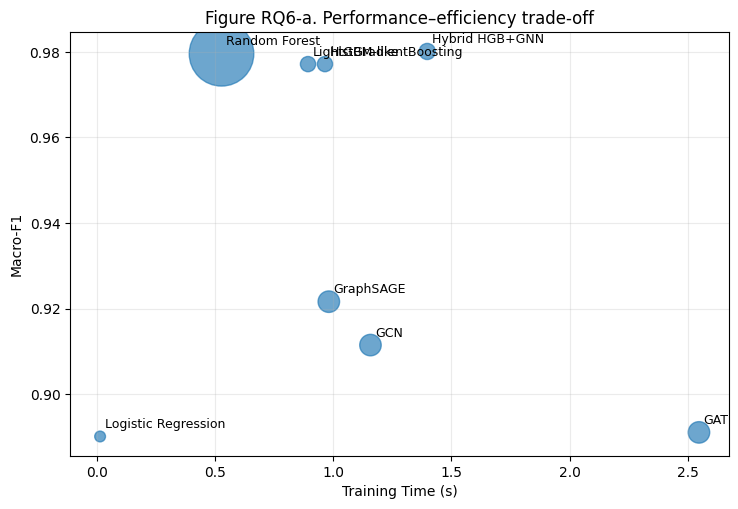

Saved:
outputs/rq6_figures/figure_rq6_a_performance_efficiency.png
outputs/rq6_figures/figure_rq6_a_performance_efficiency.pdf


In [7]:

fig, ax = plt.subplots(figsize=(8.5, 5.5))

plot_df = rq6_table_a.dropna(subset=["Training Time (s)", "Macro-F1"]).copy()
sizes = plot_df["Model Size (MB)"].fillna(1.0) * 180 + 60

ax.scatter(plot_df["Training Time (s)"], plot_df["Macro-F1"], s=sizes, alpha=0.65)

for _, row in plot_df.iterrows():
    ax.text(row["Training Time (s)"] + 0.02, row["Macro-F1"] + 0.002, row["Model"], fontsize=9)

ax.set_xlabel("Training Time (s)")
ax.set_ylabel("Macro-F1")
ax.set_title("Figure RQ6-a. Performance–efficiency trade-off")
ax.grid(alpha=0.25)

fig_a_png = RQ6_FIG_DIR / "figure_rq6_a_performance_efficiency.png"
fig_a_pdf = RQ6_FIG_DIR / "figure_rq6_a_performance_efficiency.pdf"
fig.savefig(fig_a_png, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(fig_a_pdf, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:")
print(fig_a_png)
print(fig_a_pdf)


## 7. Run scalability experiments across training fractions

In [8]:

fractions = [0.10, 0.25, 0.50, 0.75, 1.00]
scale_rows = []

def subsample_training(X_train, y_train, frac, seed=42):
    if frac >= 1.0:
        return X_train, y_train
    df_temp = X_train.copy()
    df_temp["label"] = y_train.values
    sub = df_temp.groupby("label", group_keys=False).apply(
        lambda x: x.sample(frac=frac, random_state=seed)
    )
    return sub.drop(columns=["label"]), sub["label"]

# Tabular scalability: use best boosting model
boost_name = [m for m in tab_runtime["Model"].tolist() if m in ["XGBoost", "HistGradientBoosting"]]
boost_name = boost_name[0] if boost_name else "HistGradientBoosting"

for frac in fractions:
    X_sub, y_sub = subsample_training(pack["X_train"], pack["y_train"], frac, seed=PRIMARY_SEED)

    if boost_name == "XGBoost" and XGB_AVAILABLE:
        model = XGBClassifier(
            n_estimators=250,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=PRIMARY_SEED
        )
    else:
        model = HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_depth=5,
            max_iter=250,
            random_state=PRIMARY_SEED
        )

    tr_t, inf_t, y_pred, y_prob = train_and_measure(model, X_sub, y_sub, pack["X_test"])
    met = compute_metrics(pack["y_test"], y_pred, y_prob)
    scale_rows.append({
        "Model": boost_name,
        "Training Fraction (%)": int(frac * 100),
        "Training Time (s)": tr_t,
        "Macro-F1": met["Macro-F1"]
    })

# GraphSAGE scalability if available
if PYG_AVAILABLE:
    class SAGENetSmall(torch.nn.Module):
        def __init__(self, in_dim, hidden=32):
            super().__init__()
            self.conv1 = SAGEConv(in_dim, hidden)
            self.conv2 = SAGEConv(hidden, 2)
        def forward(self, data):
            x, edge_index = data.x, data.edge_index
            h = F.relu(self.conv1(x, edge_index))
            return self.conv2(h, edge_index)

    for frac in fractions:
        X_sub, y_sub = subsample_training(pack["X_train"], pack["y_train"], frac, seed=PRIMARY_SEED)

        # rebuild graph with train subset + full test for a compact scalability approximation
        X_all = pd.concat([X_sub, pack["X_test"]], axis=0)
        y_all = pd.concat([y_sub, pack["y_test"]], axis=0)
        adj = kneighbors_graph(X_all.values, n_neighbors=5, metric="cosine", include_self=False)
        row_idx, col_idx = adj.nonzero()
        edge_index = torch.tensor(np.vstack([row_idx, col_idx]), dtype=torch.long)

        x = torch.tensor(X_all.values, dtype=torch.float32)
        y = torch.tensor(y_all.values, dtype=torch.long)
        data = Data(x=x, edge_index=edge_index, y=y)
        n_train = len(X_sub)
        train_mask = torch.zeros(len(X_all), dtype=torch.bool)
        test_mask = torch.zeros(len(X_all), dtype=torch.bool)
        train_mask[:n_train] = True
        test_mask[n_train:] = True
        data.train_mask = train_mask
        data.test_mask = test_mask

        model = SAGENetSmall(data.num_node_features, hidden=32)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
        loss_fn = torch.nn.CrossEntropyLoss()

        t0 = time.perf_counter()
        for _ in range(80):
            model.train()
            optimizer.zero_grad()
            out = model(data)
            loss = loss_fn(out[data.train_mask], data.y[data.train_mask])
            loss.backward()
            optimizer.step()
        tr_t = time.perf_counter() - t0

        model.eval()
        out = model(data)
        probs = F.softmax(out, dim=1)[:, 1].detach().cpu().numpy()
        preds = out.argmax(dim=1).detach().cpu().numpy()
        mask = data.test_mask.cpu().numpy()
        y_true = data.y[data.test_mask].cpu().numpy()
        y_prob = probs[mask]
        y_pred = preds[mask]
        met = compute_metrics(y_true, y_pred, y_prob)

        scale_rows.append({
            "Model": "GraphSAGE",
            "Training Fraction (%)": int(frac * 100),
            "Training Time (s)": tr_t,
            "Macro-F1": met["Macro-F1"]
        })

# Hybrid scalability if available
if PYG_AVAILABLE and not hybrid_runtime.empty:
    # approximate hybrid scalability using GraphSAGE embeddings from the full train/test graph built above in section 4
    for frac in fractions:
        X_sub, y_sub = subsample_training(pack["X_train"], pack["y_train"], frac, seed=PRIMARY_SEED)

        # tabular subset + matching embedding subset from GraphSAGE train embeddings
        if "GraphSAGE" in emb_bank:
            train_emb_full = emb_bank["GraphSAGE"]["train_emb"]
            n_sub = len(X_sub)
            emb_sub = pd.DataFrame(train_emb_full[:n_sub]).add_prefix("emb_")
            X_sub_h = pd.concat([X_sub.reset_index(drop=True), emb_sub.reset_index(drop=True)], axis=1)
            X_test_h = pd.concat([pack["X_test"].reset_index(drop=True), pd.DataFrame(emb_bank["GraphSAGE"]["test_emb"]).add_prefix("emb_")], axis=1)

            if XGB_AVAILABLE:
                model = XGBClassifier(
                    n_estimators=250,
                    max_depth=5,
                    learning_rate=0.05,
                    subsample=0.9,
                    colsample_bytree=0.9,
                    eval_metric="logloss",
                    random_state=PRIMARY_SEED
                )
                name = "Hybrid XGB+GNN"
            else:
                model = HistGradientBoostingClassifier(
                    learning_rate=0.05,
                    max_depth=5,
                    max_iter=250,
                    random_state=PRIMARY_SEED
                )
                name = "Hybrid HGB+GNN"

            tr_t, inf_t, y_pred, y_prob = train_and_measure(model, X_sub_h, y_sub.reset_index(drop=True), X_test_h)
            met = compute_metrics(pack["y_test"], y_pred, y_prob)
            scale_rows.append({
                "Model": name,
                "Training Fraction (%)": int(frac * 100),
                "Training Time (s)": tr_t,
                "Macro-F1": met["Macro-F1"]
            })

scalability_df = pd.DataFrame(scale_rows)
display(scalability_df)


,Model,Training Fraction (%),Training Time (s),Macro-F1
0,HistGradientBoosting,10,0.492353,0.974304
1,HistGradientBoosting,25,1.000298,0.978089
2,HistGradientBoosting,50,1.489782,0.979042
3,HistGradientBoosting,75,1.910134,0.980054
4,HistGradientBoosting,100,0.868347,0.977159
5,GraphSAGE,10,0.219118,0.911979
6,GraphSAGE,25,0.282534,0.919505
7,GraphSAGE,50,0.409561,0.916487
8,GraphSAGE,75,0.606596,0.900604
9,GraphSAGE,100,0.843302,0.918408


## 8. Generate Figure RQ6-b: scalability with increasing training data

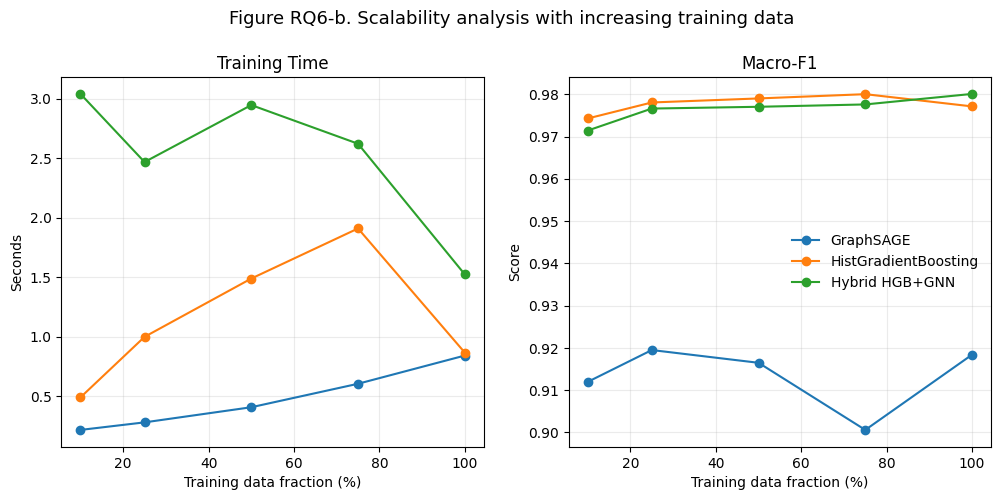

Saved:
outputs/rq6_figures/figure_rq6_b_scalability.png
outputs/rq6_figures/figure_rq6_b_scalability.pdf


In [9]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True)

for model_name, sub in scalability_df.groupby("Model"):
    sub = sub.sort_values("Training Fraction (%)")
    axes[0].plot(sub["Training Fraction (%)"], sub["Training Time (s)"], marker="o", label=model_name)
    axes[1].plot(sub["Training Fraction (%)"], sub["Macro-F1"], marker="o", label=model_name)

axes[0].set_title("Training Time")
axes[1].set_title("Macro-F1")
for ax in axes:
    ax.set_xlabel("Training data fraction (%)")
    ax.grid(alpha=0.25)
axes[0].set_ylabel("Seconds")
axes[1].set_ylabel("Score")
axes[1].legend(frameon=False)

fig.suptitle("Figure RQ6-b. Scalability analysis with increasing training data", fontsize=13, y=1.02)

fig_b_png = RQ6_FIG_DIR / "figure_rq6_b_scalability.png"
fig_b_pdf = RQ6_FIG_DIR / "figure_rq6_b_scalability.pdf"
fig.savefig(fig_b_png, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(fig_b_pdf, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:")
print(fig_b_png)
print(fig_b_pdf)


## 9. Build Table RQ6-b: joint evaluation of predictive and computational efficiency

In [10]:

summary_df = rq6_table_a.copy()

# rank lower runtime as better and higher Macro-F1 as better
summary_df["Runtime Rank"] = summary_df["Training Time (s)"].rank(method="dense", ascending=True)
summary_df["Efficiency Rank"] = ((summary_df["Runtime Rank"] + summary_df["Model Size (MB)"].fillna(summary_df["Model Size (MB)"].median()).rank(method="dense", ascending=True)) / 2.0)

# simple composite score: normalized Macro-F1 and PR-AUC minus normalized runtime penalty
def minmax(s):
    s = s.astype(float)
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

score = (
    0.45 * minmax(summary_df["Macro-F1"]) +
    0.35 * minmax(summary_df["PR-AUC"].fillna(summary_df["PR-AUC"].median())) +
    0.20 * (1 - minmax(summary_df["Training Time (s)"]))
)
summary_df["Composite Utility Score"] = score

rq6_table_b = summary_df[[
    "Model", "Macro-F1", "PR-AUC", "Runtime Rank", "Efficiency Rank", "Composite Utility Score"
]].copy()

table_b_path = RQ6_TABLE_DIR / "table_rq6_b_performance_efficiency_summary.csv"
rq6_table_b.to_csv(table_b_path, index=False)

display(rq6_table_b)
print("Saved:", table_b_path)


,Model,Macro-F1,PR-AUC,Runtime Rank,Efficiency Rank,Composite Utility Score
0,Logistic Regression,0.890085,0.973701,1.0,1.0,0.200000
1,Random Forest,0.979569,0.999397,2.0,3.0,0.956732
2,HistGradientBoosting,0.977159,0.999111,4.0,3.0,0.906238
3,LightGBM-like,0.977159,0.999111,3.0,2.5,0.911903
4,GCN,0.911456,0.986495,6.0,4.0,0.390787
5,GraphSAGE,0.921605,0.987251,5.0,3.5,0.465730
6,GAT,0.891040,0.982121,8.0,5.0,0.119463
7,Hybrid HGB+GNN,0.980112,0.999356,7.0,5.0,0.890183


Saved: outputs/rq6_tables/table_rq6_b_performance_efficiency_summary.csv


## 10. Save a compact RQ6 summary JSON

In [11]:

summary = {
    "dataset_summary": dataset_summary,
    "table_rq6_a": str(table_a_path),
    "table_rq6_b": str(table_b_path),
    "figure_rq6_a": str(RQ6_FIG_DIR / "figure_rq6_a_performance_efficiency.pdf"),
    "figure_rq6_b": str(RQ6_FIG_DIR / "figure_rq6_b_scalability.pdf"),
    "xgboost_available": bool(XGB_AVAILABLE),
    "pyg_available": bool(PYG_AVAILABLE)
}

summary_path = RQ6_TABLE_DIR / "rq6_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved summary to:", summary_path)
summary


Saved summary to: outputs/rq6_tables/rq6_summary.json


{'dataset_summary': {'shape': [14368, 46],
  'label_distribution': {1: 10894, 0: 3474},
  'missingness': {'followers_count': 0.0,
   'friends_count': 0.0,
   'statuses_count': 0.0,
   'favourites_count': 0.0,
   'listed_count': 0.0,
   'default_profile': 0.686,
   'default_profile_image': 0.9946,
   'geo_enabled': 0.7611}},
 'table_rq6_a': 'outputs/rq6_tables/table_rq6_a_computational_cost.csv',
 'table_rq6_b': 'outputs/rq6_tables/table_rq6_b_performance_efficiency_summary.csv',
 'figure_rq6_a': 'outputs/rq6_figures/figure_rq6_a_performance_efficiency.pdf',
 'figure_rq6_b': 'outputs/rq6_figures/figure_rq6_b_scalability.pdf',
 'xgboost_available': False,
 'pyg_available': True}


## 11. What this notebook produces for RQ6

After running the notebook, you will have:

### Tables
- `table_rq6_a_computational_cost.csv`
- `table_rq6_b_performance_efficiency_summary.csv`

### Figures
- `figure_rq6_a_performance_efficiency.pdf`
- `figure_rq6_b_scalability.pdf`

### Notes
- The **tabular runtime/scalability pipeline** runs immediately.
- The **graph and hybrid sections require `torch-geometric`**.
- The notebook already includes an **XGBoost fallback**.
